![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [3]:
#!sudo apt-get install libgomp1
#!sudo apt-get install libxft2
#!sudo apt-get install libglu1

Run everytime you start to execute this Jupyter Notebook

In [4]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [5]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [6]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

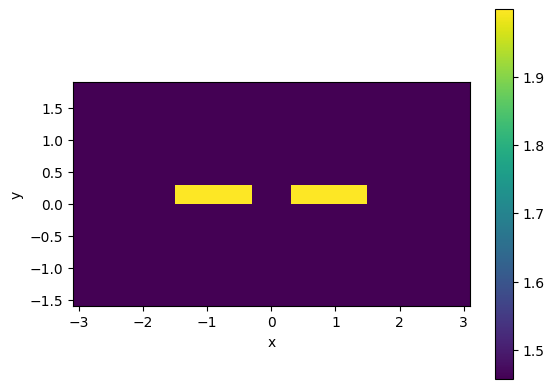

In [7]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()



### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [8]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-05-03 18:06:23.345 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cbc1bb971a882eda.npz.


[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [9]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [10]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

Text(0.5, 1.0, 'Campo Ex en el acoplador direccional (TE0)')

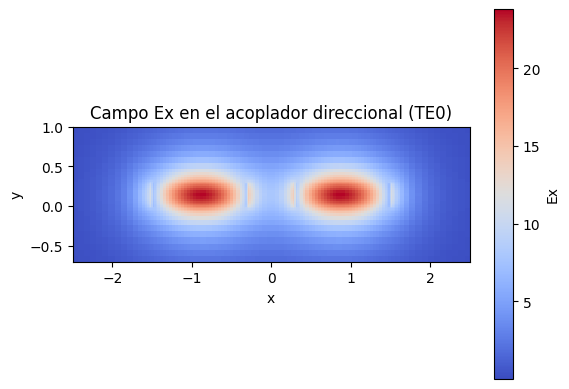

In [11]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title("Campo Ex en el acoplador direccional (TE0)")

Text(0.5, 1.0, 'Campo Ex en el acoplador direccional (TE1)')

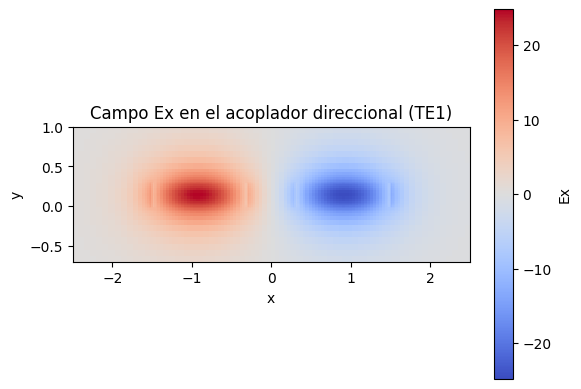

In [12]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
plt.title("Campo Ex en el acoplador direccional (TE1)")

Text(0.5, 1.0, 'Campo Ey en el acoplador direccional (TM0)')

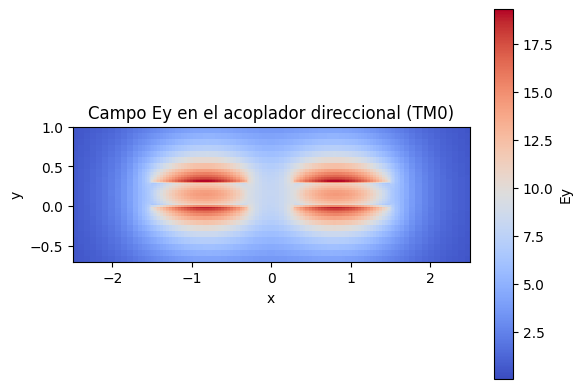

In [13]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
plt.title("Campo Ey en el acoplador direccional (TM0)")

Text(0.5, 1.0, 'Campo Ey en el acoplador direccional (TM1)')

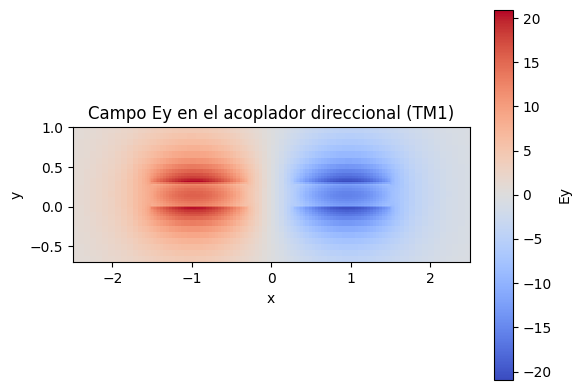

In [14]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
plt.title("Campo Ey en el acoplador direccional (TM1)")

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [15]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536699492
52.26022367744298


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [16]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

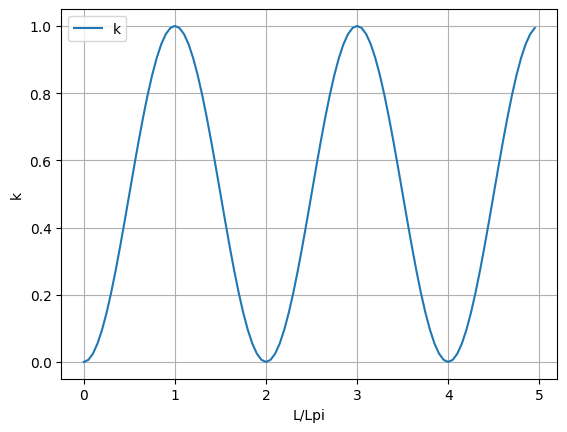

In [17]:
import math
x = np.arange(0,5,0.05)
k = np.sin(0.5*math.pi*(x))**2

plt.plot(x,k)
plt.xlabel("L/Lpi")
plt.ylabel("k")
plt.legend("k")
plt.grid()
plt.show()

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [18]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 1.2 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/madescu1/javi/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -580.4293623075473  µm


/home/madescu1/javi/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [19]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation

m.propagation()

ValueError: Number of samples, -5804, must be non-negative.

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



In [ ]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value.

L = 10000 #micras
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1, 1), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=2.5,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=3, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

gaps = np.arange(2.5,5.5,0.01)
Lpis = gt.modes.sweep_coupling_length(dcoupler_cs, gaps)
print(Lpis)


ks = np.sin(0.5*math.pi*(L/(Lpis)))**2

print(ks)


  0%|          | 0/300 [00:00<?, ?it/s]

2026-05-03 16:55:59.964 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_1c3779823ede9330.npz.
2026-05-03 16:55:59.970 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_5a98eaa774afdd4c.npz.
2026-05-03 16:55:59.975 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_5902fe4b999eaf90.npz.
2026-05-03 16:55:59.977 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_2eb39faa01928748.npz.
2026-05-03 16:55:59.981 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_912671d8822063da.npz.
2026-05-03 16:55:59.983 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8a2846998e7641b8.npz.
2026-05-03 16:55:59.985 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_4096b3621714107a.npz.
2026-05-03 16:55:59.987 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

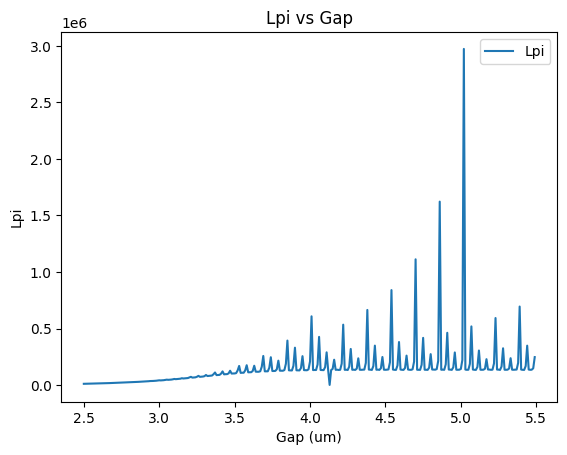

[[1.09394746e+04]
 [1.12547942e+04]
 [1.15771811e+04]
 [1.18488698e+04]
 [1.21638303e+04]
 [1.24938392e+04]
 [1.28548951e+04]
 [1.32318480e+04]
 [1.35302655e+04]
 [1.38953310e+04]
 [1.42666418e+04]
 [1.46691168e+04]
 [1.51130774e+04]
 [1.54480209e+04]
 [1.58593664e+04]
 [1.62810571e+04]
 [1.67289084e+04]
 [1.72484363e+04]
 [1.77741331e+04]
 [1.80955276e+04]
 [1.85760090e+04]
 [1.90685130e+04]
 [1.96687308e+04]
 [2.02994950e+04]
 [2.06342862e+04]
 [2.11755081e+04]
 [2.17296186e+04]
 [2.23812496e+04]
 [2.31505575e+04]
 [2.35066114e+04]
 [2.41184532e+04]
 [2.47417805e+04]
 [2.54321625e+04]
 [2.63568701e+04]
 [2.72692320e+04]
 [2.74366706e+04]
 [2.81379115e+04]
 [2.88674662e+04]
 [2.99501515e+04]
 [3.11073418e+04]
 [3.11794841e+04]
 [3.19627436e+04]
 [3.27495054e+04]
 [3.38859347e+04]
 [3.53705861e+04]
 [3.53458909e+04]
 [3.62347554e+04]
 [3.71196811e+04]
 [3.82056859e+04]
 [4.00616962e+04]
 [4.18127426e+04]
 [4.09836238e+04]
 [4.19557546e+04]
 [4.29745355e+04]
 [4.51812527e+04]
 [4.760677

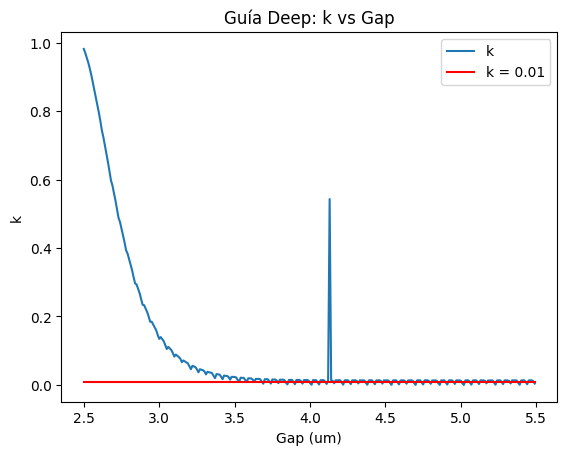

In [ ]:
plt.figure()
plt.ylim([0,1000000])
plt.plot(gaps, Lpis)
plt.plot(gaps,[156817]*np.size(gaps),'r')
plt.xlabel('Gap (um)')
plt.ylabel('Lpi')
plt.title('Lpi vs Gap')
plt.legend(['Lpi'])
plt.show()

plt.figure()
plt.plot(gaps, ks)
plt.plot(gaps,[0.01]*np.size(gaps),'r')
plt.xlabel('Gap (um)')
plt.ylabel('k')
plt.title('Guía Deep: k vs Gap')
plt.legend(['k','k = 0.01'])
plt.show()

In [ ]:
print(Lpis)
print(ks)

[[  17.68931576   16.71944102]
 [  32.68739325   25.44557929]
 [  58.77155395   38.42630859]
 [ 103.11225695   56.51294353]
 [ 183.51013066   85.34871817]
 [ 320.54361015  125.67039484]
 [ 556.78378585  183.82067989]
 [ 963.20196971  267.42886782]
 [ 878.42286291  344.27902177]
 [2855.02591098  558.72946123]
 [4898.71406454  803.35875027]
 [8380.02705281 1151.93405824]]
[[9.81912401e-01]
 [9.69642558e-01]
 [9.54901937e-01]
 [9.41117770e-01]
 [9.23930159e-01]
 [9.04872414e-01]
 [8.83159502e-01]
 [8.59884547e-01]
 [8.41223026e-01]
 [8.18307810e-01]
 [7.95080572e-01]
 [7.70169904e-01]
 [7.43184078e-01]
 [7.23253372e-01]
 [6.99355313e-01]
 [6.75577133e-01]
 [6.51169760e-01]
 [6.23983867e-01]
 [5.97722857e-01]
 [5.82283595e-01]
 [5.60061298e-01]
 [5.38328655e-01]
 [5.13226470e-01]
 [4.88413418e-01]
 [4.75866688e-01]
 [4.56455717e-01]
 [4.37647196e-01]
 [4.16826132e-01]
 [3.93927430e-01]
 [3.83907055e-01]
 [3.67488258e-01]
 [3.51741159e-01]
 [3.35373199e-01]
 [3.15073025e-01]
 [2.96699122e-0

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [ ]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

2026-05-03 16:24:24.044 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [ ]:
mmi_body_waveguide.fraction_te


array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

Text(0.5, 1.0, 'Campo Ex en el MMI (TE0)')

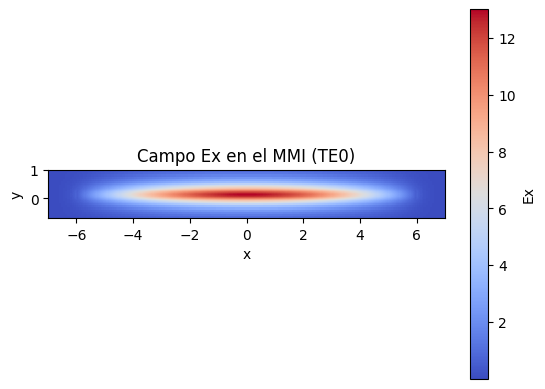

In [ ]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title("Campo Ex en el MMI (TE0)")

Text(0.5, 1.0, 'Campo Ex en el MMI (TE1)')

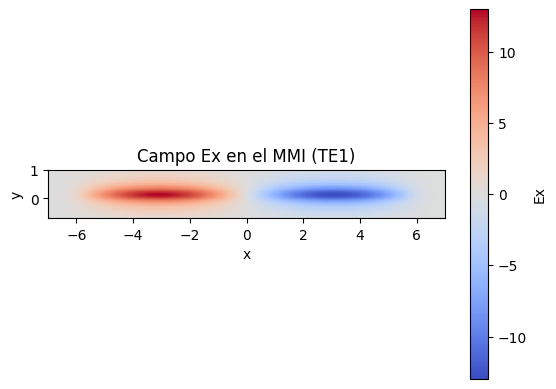

In [ ]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
plt.title("Campo Ex en el MMI (TE1)")

Text(0.5, 1.0, 'Campo Ex en el MMI (TE7)')

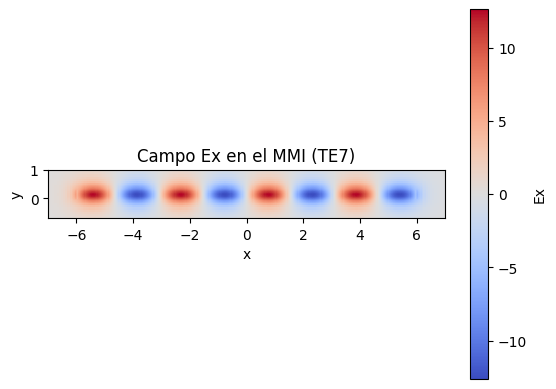

In [ ]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #
plt.title("Campo Ex en el MMI (TE7)")

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [ ]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794412975


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [ ]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/javie/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256005  µm


/home/javie/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


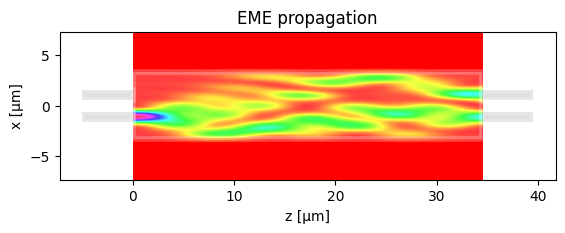

In [ ]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/684 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.3000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9162
Excess loss [dB] =  0.3800
------------------------
Power over OUTs:  ['0.4670', '0.4492']
Ratio over OUTs ['0.5097', '0.4903']


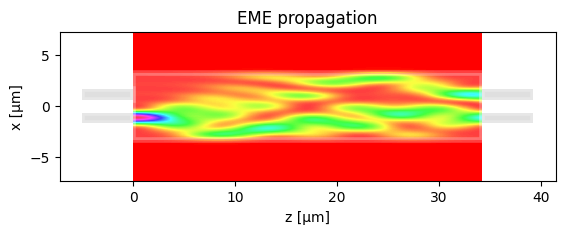

In [ ]:
dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.3  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [ ]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 1 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/javie/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256005  µm


/home/javie/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/684 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.3000
IO wg width 1.0000
IO wg width increment 1.0000
------------------------
Total power IN coupled 0.9984
Total OUT power: 0.9967
Excess loss [dB] =  0.0143
------------------------
Power over OUTs:  ['0.5070', '0.4897']
Ratio over OUTs ['0.5087', '0.4913']


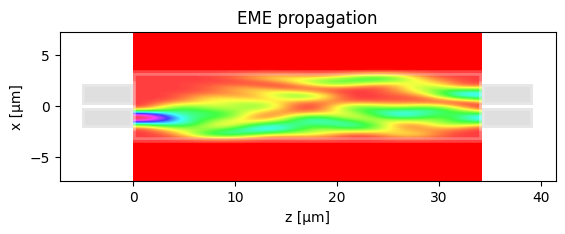

In [ ]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.3 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [ ]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 12 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/javie/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  219.13931544115098  µm


/home/javie/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/822 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9329
Total OUT power: 0.5275
Excess loss [dB] =  2.7782
------------------------
Power over OUTs:  ['0.1002', '0.1635', '0.1636', '0.1001']
Ratio over OUTs ['0.1899', '0.3100', '0.3102', '0.1898']


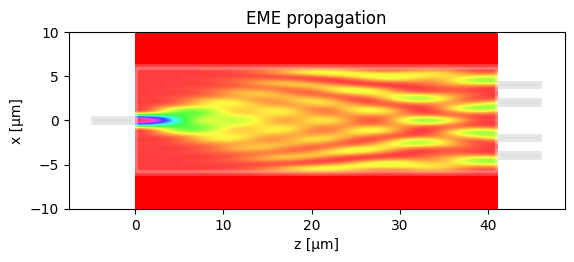

In [ ]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  1 # STUDENT
m.n_OUT = 4 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([0]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-2/6,-1/6,1/6,2/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (3/16)*L_pi # STUDENT

# Run propagation
m.propagation()

### Optimization 1

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/796 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -1.3000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9329
Total OUT power: 0.8634
Excess loss [dB] =  0.6378
------------------------
Power over OUTs:  ['0.2158', '0.2160', '0.2160', '0.2157']
Ratio over OUTs ['0.2499', '0.2502', '0.2501', '0.2498']


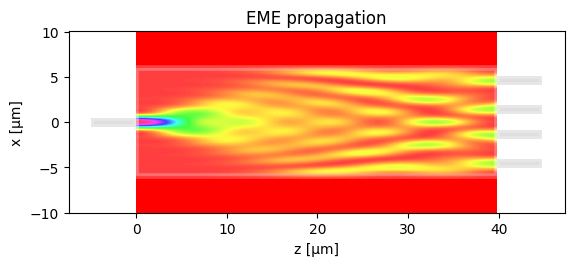

In [ ]:
dy = 0.6
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([0])
m.OUT_WVG_positions = mmi_Width*np.array([-2/6,-1/6,1/6,2/6]) + np.array([-dy,dy,-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -1.3  # STUDENT

# Run propagation
m.propagation()

### Optimization 2

In [ ]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 12   # MMI width
m.wg_width_dw = 1.3 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/javie/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  219.13931544091707  µm


/home/javie/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/796 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -1.3000
IO wg width 1.0000
IO wg width increment 1.3000
------------------------
Total power IN coupled 0.9978
Total OUT power: 0.9778
Excess loss [dB] =  0.0975
------------------------
Power over OUTs:  ['0.2420', '0.2469', '0.2470', '0.2419']
Ratio over OUTs ['0.2475', '0.2525', '0.2526', '0.2474']


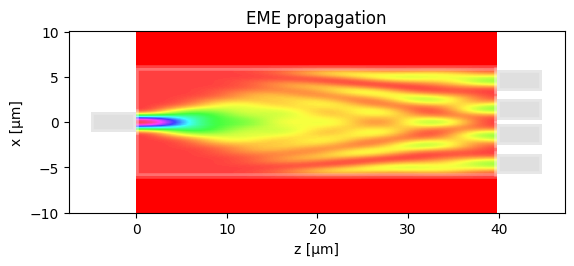

In [ ]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 1 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.63
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([0])
m.OUT_WVG_positions = mmi_Width*np.array([-2/6,-1/6,1/6,2/6]) + np.array([-dy,dy,-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -1.3  # STUDENT
# MMI length (check class slides for type of MMI)
m.L_MMI = (3/16)*L_pi  # STUDENT
# Run propagation
m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

In [47]:
import os
import sys
import warnings
import contextlib
import logging
from loguru import logger

warnings.filterwarnings("ignore", category=FutureWarning)

logging.getLogger("gplugins").setLevel(logging.ERROR)
logging.getLogger("tidy3d").setLevel(logging.ERROR)

try:
    logger.remove()
except Exception:
    pass


@contextlib.contextmanager
def suppress_console_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        try:
            sys.stdout = devnull
            sys.stderr = devnull
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

In [48]:
lambda_c = 1.55
gaps = np.arange(0.2, 2.6, 0.2)

num_modes = 9
valid_simulation = False

while not valid_simulation:

    print(f"\nIntentando simulación con num_modes = {num_modes}")

    # Vectores temporales para esta simulación
    Lpi_TE_values_temp = []
    Lpi_TM_values_temp = []

    te_modes_all = []
    tm_modes_all = []

    valid_simulation = True

    for gap in gaps:

        with suppress_console_output():
            dcoupler_cs = gt.modes.WaveguideCoupler(
                wavelength=[lambda_c],
                core_width=(1.0, 1.0),
                gap=gap,
                slab_thickness=150 * nm,
                core_material='sin',
                clad_material='sio2',
                core_thickness=300 * nm,
                num_modes=num_modes,
                cache_path='.cache/',
                precision='double',
                max_grid_scaling=1.5,
                grid_resolution=20
            )

        # Sacar índices efectivos y fraction_te
        dcoupler_neff = dcoupler_cs.n_eff
        fraction_te = dcoupler_cs.fraction_te

        # Buscar modos TE y TM
        te_modes = []
        tm_modes = []

        for i, fte in enumerate(fraction_te):
            if np.isclose(fte, 1, atol=0.2):
                te_modes.append(i)
            elif np.isclose(fte, 0, atol=0.2):
                tm_modes.append(i)

        # Si para este gap no hay al menos 2 TE y 2 TM,
        # la simulación completa no es válida
        if len(te_modes) < 2 or len(tm_modes) < 2:
            print(f"Gap = {gap:.2f} um no válido")
            print(f"  TE encontrados: {te_modes}")
            print(f"  TM encontrados: {tm_modes}")
            print("  Incrementando num_modes y repitiendo todos los gaps...")

            valid_simulation = False
            num_modes += 1
            break

        # Calcular Lpi_TE usando los dos primeros modos TE encontrados
        i0, i1 = te_modes[0], te_modes[1]
        L_pi_TE = 0.5 * lambda_c / abs(
            dcoupler_neff[i0].real - dcoupler_neff[i1].real
        )

        # Calcular Lpi_TM usando los dos primeros modos TM encontrados
        i0, i1 = tm_modes[0], tm_modes[1]
        L_pi_TM = 0.5 * lambda_c / abs(
            dcoupler_neff[i0].real - dcoupler_neff[i1].real
        )

        # Guardar resultados temporales
        Lpi_TE_values_temp.append(L_pi_TE)
        Lpi_TM_values_temp.append(L_pi_TM)

        te_modes_all.append(te_modes[:2])
        tm_modes_all.append(tm_modes[:2])

        print(f"Gap = {gap:.2f} um")
        print(f"  TE modes: {te_modes[:2]} -> Lpi_TE = {L_pi_TE}")
        print(f"  TM modes: {tm_modes[:2]} -> Lpi_TM = {L_pi_TM}")

# Si llega aquí, todos los gaps son válidos
Lpi_TE_values = np.array(Lpi_TE_values_temp)
Lpi_TM_values = np.array(Lpi_TM_values_temp)

print(f"\nSimulación completada correctamente con num_modes = {num_modes}")


Intentando simulación con num_modes = 9
Gap = 0.20 um
  TE modes: [0, 1] -> Lpi_TE = 17.71068783997895
  TM modes: [2, 5] -> Lpi_TM = 18.56487634494641
Gap = 0.40 um
  TE modes: [0, 1] -> Lpi_TE = 26.4510437602962
  TM modes: [2, 5] -> Lpi_TM = 25.165163650286217
Gap = 0.60 um
  TE modes: [0, 1] -> Lpi_TE = 39.25252888638868
  TM modes: [2, 5] -> Lpi_TM = 33.861488213605625
Gap = 0.80 um
  TE modes: [0, 1] -> Lpi_TE = 57.94806687862188
  TM modes: [2, 5] -> Lpi_TM = 44.52100860894181
Gap = 1.00 um
  TE modes: [0, 1] -> Lpi_TE = 85.76271990311038
  TM modes: [2, 7] -> Lpi_TM = 9.650563499098089
Gap = 1.20 um
  TE modes: [0, 1] -> Lpi_TE = 126.35514622753344
  TM modes: [2, 4] -> Lpi_TM = 73.09259361032987
Gap = 1.40 um
  TE modes: [0, 1] -> Lpi_TE = 185.8672076165865
  TM modes: [2, 7] -> Lpi_TM = 10.498310994218318
Gap = 1.60 um no válido
  TE encontrados: [0, 1, 5, 6]
  TM encontrados: [2]
  Incrementando num_modes y repitiendo todos los gaps...

Intentando simulación con num_modes =

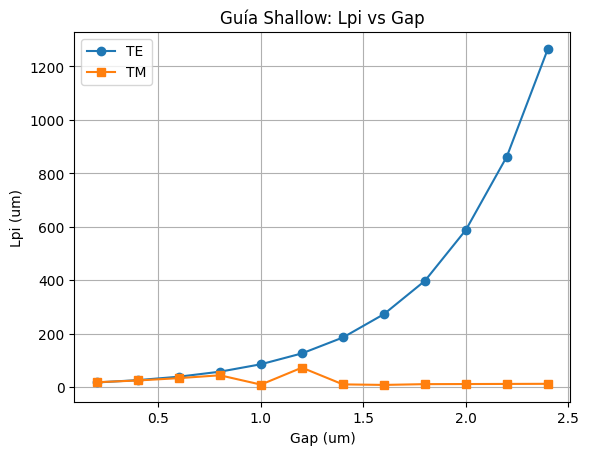

In [49]:
plt.figure()
plt.plot(gaps, Lpi_TE_values, 'o-', label='TE')
plt.plot(gaps, Lpi_TM_values, 's-', label='TM')
# plt.ylim([0,1200])
plt.xlabel('Gap (um)')
plt.ylabel('Lpi (um)')
plt.title('Guía Shallow: Lpi vs Gap')
plt.grid(True)
plt.legend()
plt.show()


### E2. Directional coupler wavelength dependence


Intentando simulación con num_modes = 9
Wavelength = 1.500 um
  TE modes: [0, 1] -> Lpi_TE = 42.4524375645943
  TM modes: [2, 5] -> Lpi_TM = 35.10207008656327
Wavelength = 1.520 um
  TE modes: [0, 1] -> Lpi_TE = 41.15810592878565
  TM modes: [2, 5] -> Lpi_TM = 35.46799644201471
Wavelength = 1.540 um
  TE modes: [0, 1] -> Lpi_TE = 39.604628724209256
  TM modes: [2, 3] -> Lpi_TM = 36.05092013273379
Wavelength = 1.560 um
  TE modes: [0, 1] -> Lpi_TE = 38.71723999980109
  TM modes: [3, 5] -> Lpi_TM = 34.67656019510125
Wavelength = 1.580 um
  TE modes: [0, 1] -> Lpi_TE = 37.70522756398193
  TM modes: [2, 5] -> Lpi_TM = 33.44220934555536
Wavelength = 1.600 um
  TE modes: [0, 1] -> Lpi_TE = 36.78382300756821
  TM modes: [3, 5] -> Lpi_TM = 32.78027121495272
Wavelength = 1.620 um
  TE modes: [0, 1] -> Lpi_TE = 34.86166091663648
  TM modes: [2, 5] -> Lpi_TM = 32.66009375398219
Wavelength = 1.640 um
  TE modes: [0, 1] -> Lpi_TE = 35.25858278798822
  TM modes: [3, 5] -> Lpi_TM = 31.75761671617508

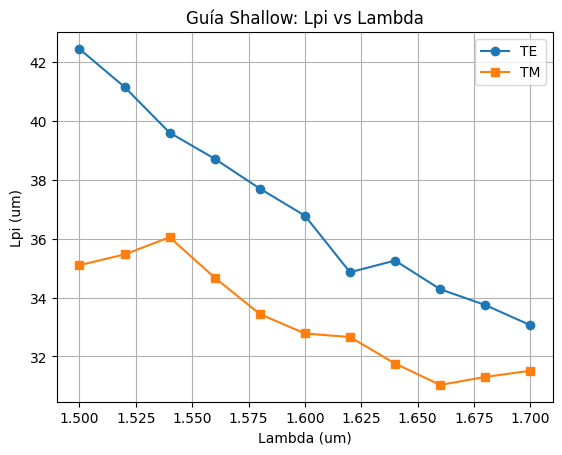

In [80]:
wavelengths = np.arange(1.5, 1.7 + 0.02, 0.02)

gap = 0.6
width = 1.0

num_modes = 9
valid_simulation = False

shallow1_deep0 = 1

while not valid_simulation:

    print(f"\nIntentando simulación con num_modes = {num_modes}")

    # Vectores temporales para esta simulación
    Lpi_TE_values_temp = []
    Lpi_TM_values_temp = []

    te_modes_all = []
    tm_modes_all = []

    valid_simulation = True

    for lambda_c in wavelengths:

        with suppress_console_output():
            dcoupler_cs = gt.modes.WaveguideCoupler(
                wavelength=[lambda_c],
                core_width=(width, width),
                gap=gap,
                slab_thickness=150 * shallow1_deep0 * nm,
                core_material='sin',
                clad_material='sio2',
                core_thickness=300 * nm,
                num_modes=num_modes,
                cache_path='.cache/',
                precision='double',
                max_grid_scaling=1.5,
                grid_resolution=20
            )

        # Sacar índices efectivos y fraction_te
        dcoupler_neff = dcoupler_cs.n_eff
        fraction_te = dcoupler_cs.fraction_te

        # Buscar modos TE y TM
        te_modes = []
        tm_modes = []

        for i, fte in enumerate(fraction_te):
            if np.isclose(fte, 1, atol=0.2):
                te_modes.append(i)
            elif np.isclose(fte, 0, atol=0.2):
                tm_modes.append(i)

        # Si para esta wavelength no hay al menos 2 TE y 2 TM,
        # la simulación completa no es válida
        if len(te_modes) < 2 or len(tm_modes) < 2:
            print(f"Wavelength = {lambda_c:.3f} um no válida")
            print(f"  TE encontrados: {te_modes}")
            print(f"  TM encontrados: {tm_modes}")
            print("  Incrementando num_modes y repitiendo todas las wavelengths...")

            valid_simulation = False
            num_modes += 1
            break

        # Calcular Lpi_TE usando los dos primeros modos TE encontrados
        i0, i1 = te_modes[0], te_modes[1]
        L_pi_TE = 0.5 * lambda_c / abs(
            dcoupler_neff[i0].real - dcoupler_neff[i1].real
        )

        # Calcular Lpi_TM usando los dos primeros modos TM encontrados
        i0, i1 = tm_modes[0], tm_modes[1]
        L_pi_TM = 0.5 * lambda_c / abs(
            dcoupler_neff[i0].real - dcoupler_neff[i1].real
        )

        # Guardar resultados temporales
        Lpi_TE_values_temp.append(L_pi_TE)
        Lpi_TM_values_temp.append(L_pi_TM)

        te_modes_all.append(te_modes[:2])
        tm_modes_all.append(tm_modes[:2])

        print(f"Wavelength = {lambda_c:.3f} um")
        print(f"  TE modes: {te_modes[:2]} -> Lpi_TE = {L_pi_TE}")
        print(f"  TM modes: {tm_modes[:2]} -> Lpi_TM = {L_pi_TM}")

# Si llega aquí, todas las wavelengths son válidas
Lpi_TE_values = np.array(Lpi_TE_values_temp)
Lpi_TM_values = np.array(Lpi_TM_values_temp)

print(f"\nSimulación completada correctamente con num_modes = {num_modes}")

plt.figure()
plt.plot(wavelengths, Lpi_TE_values, "o-", label="TE")
plt.plot(wavelengths, Lpi_TM_values, "s-", label="TM")

plt.xlabel("Lambda (um)")
plt.ylabel("Lpi (um)")
plt.title("Guía {}: Lpi vs Lambda".format("Shallow" if shallow1_deep0 else "Deep"))
plt.grid(True)
plt.legend()
plt.show()


### E3. MMI coupler wavelength dependence


Intentando simulación con num_modes = 4
Wavelength = 1.500 um no válida
  TE encontrados: [0, 1, 2, 3]
  TM encontrados: []
  Incrementando num_modes y repitiendo todas las wavelengths...

Intentando simulación con num_modes = 5
Wavelength = 1.500 um no válida
  TE encontrados: [0, 1, 2, 3, 4]
  TM encontrados: []
  Incrementando num_modes y repitiendo todas las wavelengths...

Intentando simulación con num_modes = 6
Wavelength = 1.500 um no válida
  TE encontrados: [0, 1, 2, 3, 4]
  TM encontrados: [5]
  Incrementando num_modes y repitiendo todas las wavelengths...

Intentando simulación con num_modes = 7
Wavelength = 1.500 um
  TE modes: [0, 1] -> Lpi_TE = 76.2153138651377
  TM modes: [5, 6] -> Lpi_TM = 78.50653980233261
Wavelength = 1.520 um no válida
  TE encontrados: [0, 1, 2, 3, 4, 6]
  TM encontrados: [5]
  Incrementando num_modes y repitiendo todas las wavelengths...

Intentando simulación con num_modes = 8
Wavelength = 1.500 um
  TE modes: [0, 1] -> Lpi_TE = 76.21531386513598

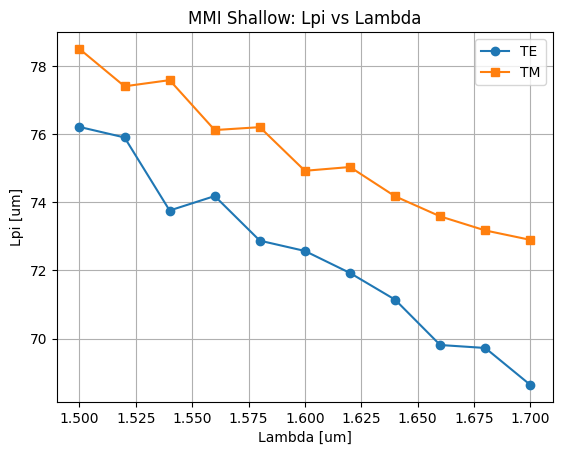

In [82]:
mmi_body_w = 6.6
wavelengths = np.arange(1.5, 1.7 + 0.02, 0.02)

num_modes = 4
valid_simulation = False

shallow1_deep0 = 1

while not valid_simulation:

    print(f"\nIntentando simulación con num_modes = {num_modes}")

    # Vectores temporales para esta simulación
    Lpi_TE_values_temp = []
    Lpi_TM_values_temp = []

    te_modes_all = []
    tm_modes_all = []

    valid_simulation = True

    for lambda_c in wavelengths:

        with suppress_console_output():
            mmi_body_waveguide = gt.modes.Waveguide(
                # Geometrical Parameters
                core_width=mmi_body_w,
                core_thickness=300 * nm,
                slab_thickness=150 * shallow1_deep0 * nm,

                # Materials
                core_material='sin',
                clad_material='sio2',

                # Modesolver Parameters
                wavelength=lambda_c,
                num_modes=num_modes,
                max_grid_scaling=1.5,
                grid_resolution=20,
                cache_path='.cache/',
                precision='double',
            )

        # Sacar índices efectivos y fraction_te
        mmi_neff = mmi_body_waveguide.n_eff
        fraction_te = mmi_body_waveguide.fraction_te

        # Buscar modos TE y TM
        te_modes = []
        tm_modes = []

        for i, fte in enumerate(fraction_te):
            if np.isclose(fte, 1, atol=0.2):
                te_modes.append(i)
            elif np.isclose(fte, 0, atol=0.2):
                tm_modes.append(i)

        # Si para esta wavelength no hay al menos 2 TE y 2 TM,
        # la simulación completa no es válida
        if len(te_modes) < 2 or len(tm_modes) < 2:
            print(f"Wavelength = {lambda_c:.3f} um no válida")
            print(f"  TE encontrados: {te_modes}")
            print(f"  TM encontrados: {tm_modes}")
            print("  Incrementando num_modes y repitiendo todas las wavelengths...")

            valid_simulation = False
            num_modes += 1
            break

        # Calcular Lpi_TE usando los dos primeros modos TE encontrados
        i0, i1 = te_modes[0], te_modes[1]

        d_n_eff_TE = abs(
            mmi_neff[i0].real - mmi_neff[i1].real
        )

        L_pi_TE = 0.5 * lambda_c / d_n_eff_TE

        # Calcular Lpi_TM usando los dos primeros modos TM encontrados
        i0, i1 = tm_modes[0], tm_modes[1]

        d_n_eff_TM = abs(
            mmi_neff[i0].real - mmi_neff[i1].real
        )

        L_pi_TM = 0.5 * lambda_c / d_n_eff_TM

        # Guardar resultados temporales
        Lpi_TE_values_temp.append(L_pi_TE)
        Lpi_TM_values_temp.append(L_pi_TM)

        te_modes_all.append(te_modes[:2])
        tm_modes_all.append(tm_modes[:2])

        print(f"Wavelength = {lambda_c:.3f} um")
        print(f"  TE modes: {te_modes[:2]} -> Lpi_TE = {L_pi_TE}")
        print(f"  TM modes: {tm_modes[:2]} -> Lpi_TM = {L_pi_TM}")

# Si llega aquí, todas las wavelengths son válidas
Lpi_TE_values = np.array(Lpi_TE_values_temp)
Lpi_TM_values = np.array(Lpi_TM_values_temp)

print(f"\nSimulación completada correctamente con num_modes = {num_modes}")

plt.figure()
plt.plot(wavelengths, Lpi_TE_values, "o-", label="TE")
plt.plot(wavelengths, Lpi_TM_values, "s-", label="TM")

plt.xlabel("Lambda [um]")
plt.ylabel("Lpi [um]")
plt.title("MMI {}: Lpi vs Lambda".format("Shallow" if shallow1_deep0 else "Deep"))

plt.grid(True)
plt.legend()
plt.show()

### E4. MMI coupler body width dependence


Intentando simulación con num_modes = 9
wMMI = 5.00 um
  TE modes: [0, 1] -> Lpi_TE = 44.84714214166026
  TM modes: [4, 5] -> Lpi_TM = 48.38603452123877
wMMI = 5.50 um
  TE modes: [0, 1] -> Lpi_TE = 53.16193934805564
  TM modes: [4, 7] -> Lpi_TM = 21.411981423951385
wMMI = 6.00 um
  TE modes: [0, 1] -> Lpi_TE = 62.206329264148245
  TM modes: [4, 6] -> Lpi_TM = 64.85966065536286
wMMI = 6.50 um
  TE modes: [0, 1] -> Lpi_TE = 71.9776844641581
  TM modes: [5, 6] -> Lpi_TM = 74.76824675470434
wMMI = 7.00 um
  TE modes: [0, 1] -> Lpi_TE = 82.57029157780455
  TM modes: [5, 6] -> Lpi_TM = 85.55260730074566
wMMI = 7.50 um
  TE modes: [0, 1] -> Lpi_TE = 93.79786656796031
  TM modes: [6, 7] -> Lpi_TM = 97.9383287485591
wMMI = 8.00 um
  TE modes: [0, 1] -> Lpi_TE = 105.6381214775445
  TM modes: [6, 7] -> Lpi_TM = 108.55164273780888
wMMI = 8.50 um no válido
  TE encontrados: [0, 1, 2, 3, 4, 5, 8]
  TM encontrados: [6]
  Incrementando num_modes y repitiendo todos los widths...

Intentando simulació

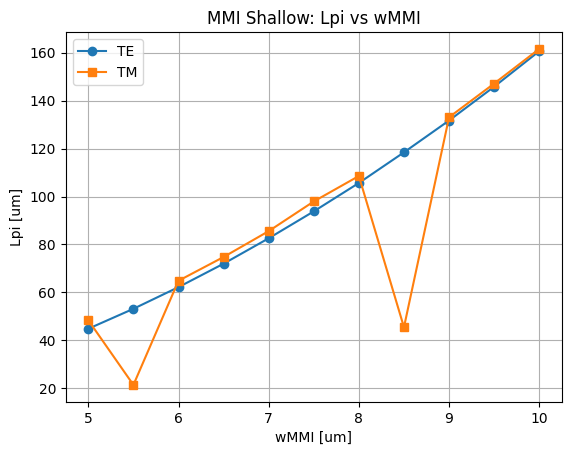

In [76]:
lambda_c = 1.55
mmi_widths = np.arange(5.0, 10.0 + 0.5, 0.5)

num_modes = 9
valid_simulation = False

shallow1_deep0 = 1

while not valid_simulation:

    print(f"\nIntentando simulación con num_modes = {num_modes}")

    # Vectores temporales para esta simulación
    Lpi_TE_values_temp = []
    Lpi_TM_values_temp = []

    te_modes_all = []
    tm_modes_all = []

    valid_simulation = True

    for mmi_body_w in mmi_widths:

        with suppress_console_output():
            mmi_body_waveguide = gt.modes.Waveguide(
                # Geometrical Parameters
                core_width=mmi_body_w,
                core_thickness=300 * nm,
                slab_thickness=150 * shallow1_deep0 * nm,

                # Materials
                core_material='sin',
                clad_material='sio2',

                # Modesolver Parameters
                wavelength=lambda_c,
                num_modes=num_modes,
                max_grid_scaling=1.5,
                grid_resolution=20,
                cache_path='.cache/',
                precision='double',
            )

        # Sacar índices efectivos y fraction_te
        mmi_neff = mmi_body_waveguide.n_eff
        fraction_te = mmi_body_waveguide.fraction_te

        # Buscar modos TE y TM
        te_modes = []
        tm_modes = []

        for i, fte in enumerate(fraction_te):
            if np.isclose(fte, 1, atol=0.2):
                te_modes.append(i)
            elif np.isclose(fte, 0, atol=0.2):
                tm_modes.append(i)

        # Si para este width no hay al menos 2 TE y 2 TM,
        # la simulación completa no es válida
        if len(te_modes) < 2 or len(tm_modes) < 2:
            print(f"wMMI = {mmi_body_w:.2f} um no válido")
            print(f"  TE encontrados: {te_modes}")
            print(f"  TM encontrados: {tm_modes}")
            print("  Incrementando num_modes y repitiendo todos los widths...")

            valid_simulation = False
            num_modes += 1
            break

        # Calcular Lpi_TE usando los dos primeros modos TE encontrados
        i0, i1 = te_modes[0], te_modes[1]

        d_n_eff_TE = abs(
            mmi_neff[i0].real - mmi_neff[i1].real
        )

        L_pi_TE = 0.5 * lambda_c / d_n_eff_TE

        # Calcular Lpi_TM usando los dos primeros modos TM encontrados
        i0, i1 = tm_modes[0], tm_modes[1]

        d_n_eff_TM = abs(
            mmi_neff[i0].real - mmi_neff[i1].real
        )

        L_pi_TM = 0.5 * lambda_c / d_n_eff_TM

        # Guardar resultados temporales
        Lpi_TE_values_temp.append(L_pi_TE)
        Lpi_TM_values_temp.append(L_pi_TM)

        te_modes_all.append(te_modes[:2])
        tm_modes_all.append(tm_modes[:2])

        print(f"wMMI = {mmi_body_w:.2f} um")
        print(f"  TE modes: {te_modes[:2]} -> Lpi_TE = {L_pi_TE}")
        print(f"  TM modes: {tm_modes[:2]} -> Lpi_TM = {L_pi_TM}")

# Si llega aquí, todos los widths son válidos
Lpi_TE_values = np.array(Lpi_TE_values_temp)
Lpi_TM_values = np.array(Lpi_TM_values_temp)

print(f"\nSimulación completada correctamente con num_modes = {num_modes}")

plt.figure()
plt.plot(mmi_widths, Lpi_TE_values, "o-", label="TE")
plt.plot(mmi_widths, Lpi_TM_values, "s-", label="TM")

plt.xlabel("wMMI [um]")
plt.ylabel("Lpi [um]")
plt.title("MMI {}: Lpi vs wMMI".format("Shallow" if shallow1_deep0 else "Deep"))

plt.grid(True)
plt.legend()
plt.show()

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points